In [1]:
import openslide
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import json
from modules.mhim import MHIM
from modules.mean_max2 import DAttention
import cv2
import random
import seaborn as sns
import os
from copy import deepcopy
from download import find_model
from models import DiT_models

/home/shihuazhan/anaconda3/envs/odise/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_area(pos_anchors,margin_percentage = 2,center_anchors=None,width_height=None):
    if center_anchors is not None:
        margin = 10 * 512 * margin_percentage / 2
        center_anchor = (center_anchors[1],center_anchors[0])
    else:
        top, down, left, right = min(pos_anchors[:, 1]), max(pos_anchors[:, 1]), min(pos_anchors[:, 0]), max(pos_anchors[:, 0])
        center_anchor = ((top + down) // 2, (left + right) // 2)
        margin = max((down - top), (right - left)) * margin_percentage / 2

    top, down, left, right = np.array(
        [center_anchor[0]-margin, center_anchor[0]+margin, center_anchor[1]-margin, center_anchor[1]+margin],
        dtype=int
    )
    ori_coord = np.array([down,top,right,left])
    top,down,left,right = np.clip(top,0,width_height[1]),np.clip(down,0,width_height[1]),np.clip(left,0,width_height[0]),np.clip(right,0,width_height[0])
    _gap = np.array([down,top,right,left]) 
    _coord = np.array([top,down,left,right]) 
    top,down,left,right = _coord + (_gap - ori_coord)

    return top,down,left,right,(down-top) * (right-left)
    
def screen_coords(scores, coords, top_left, bot_right,cam=None):
    bot_right = np.array(bot_right)
    top_left = np.array(top_left)
    mask = np.logical_and(np.all(coords >= top_left, axis=1), np.all(coords <= bot_right, axis=1))
    if cam is not None:
        return scores[mask], coords[mask], cam[mask]
    else:
        return scores[mask], coords[mask]

def random_area(width,height,min_area,max_area):
    while True:
        left = random.randint(0, width - 1)
        top = random.randint(0, height - 1)
        right = random.randint(left + 1, width)
        down = random.randint(top + 1, height)
        area = (right - left) * (down - top)
        if min_area <= area <= max_area:
            return (top, left, down, right)

In [ ]:
# MHIM
mask = MHIM(da_act='relu',baseline='selfattn').eval()
mask.requires_grad_(False)

mask_cpt = torch.load('/data/shihuazhan/output_wsi/mhim/mhim.pt',map_location='cpu')

mask.load_state_dict(mask_cpt['model'])


In [3]:
#diff
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

#diffSim
from modules.diffmil import fastDAttentionWithDiffEnd as diffSim
Dit= (DiT_models["DiT-XL/2"](input_size=32)).to(device)
ckpt_path = "/home/shihuazhan/DiT/DiT/pretrained_models/DiT-XL-2-256x256.pt"
# ckpt_path = "/data/zhangxiaoxian/output/pretrained_models/DiT-XL-2-256x256.pt"
state_dict = find_model(ckpt_path)
Dit.load_state_dict(state_dict)
Dit.eval()

DiT(
  (x_embedder): PatchEmbed(
    (proj): Conv2d(4, 1152, kernel_size=(2, 2), stride=(2, 2))
    (norm): Identity()
  )
  (t_embedder): TimestepEmbedder(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=1152, bias=True)
      (1): SiLU()
      (2): Linear(in_features=1152, out_features=1152, bias=True)
    )
  )
  (y_embedder): LabelEmbedder(
    (embedding_table): Embedding(1001, 1152)
  )
  (blocks): ModuleList(
    (0): DiTBlock(
      (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      (attn): Attention(
        (qkv): Linear(in_features=1152, out_features=3456, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1152, out_features=1152, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      (mlp): Mlp(
        (fc1): Linear(in_features=1152, out_features=4608, bias=True)
        (act): GELU(approximate=

In [4]:
#diffSim
# from modules.diffmil import DAttentionWithDiffEnd as diffSim
# mask = diffSim(out_dim=2,k_ratio=0.5,t_steps=2,ifrand=2,ifTrain=1,a_ratio=1.0,adapter_ratio=0.1,a_num=1).eval()
# mask.requires_grad_(False)

# mask_cpt = torch.load('/data/shihuazhan/output_wsi/mil_shz/slowcall_twh_mean_0.5_samex1_x2_train_emd_adapter0.1/fold_3_model_best_auc.pt',map_location='cpu')

# mask.load_state_dict(mask_cpt['model'])

mask = diffSim(out_dim=2,k_ratio=0.2,t_steps=2,ifrand=2,ifTrain=1,a_ratio=1.0,adapter_ratio=0.1).eval()
mask.requires_grad_(False)

#mask_cpt = torch.load('/data/shihuazhan/output_wsi/mil_shz/slowcall_twh_mean_0.5_samex1_x2_train_emd_adapter0.1/fold_3_model_best_auc.pt',map_location='cpu')
mask_cpt = torch.load('/data/shihuazhan/output_wsi/mil_shz/fastcall_twh_mean_0.5_samex1_x2_train_emd_adapter1.0/fold_3_model_best_auc.pt',map_location='cpu')

mask.load_state_dict(mask_cpt['model'])

<All keys matched successfully>

In [ ]:
# # AB-MIL
#     elif args.model == 'attmil':
#         model = attmil.DAttention(n_classes=args.n_classes,dropout=args.dropout,act=args.act).to(device)
# pure = MHIM(da_act='relu',baseline='attn').eval()
# pure = DAttention(n_classes=2,dropout=0.25,act='relu').eval()
pure= DAttention(out_dim=2,n_robust=0).eval() 

pure.requires_grad_(False)

pure_cpt = torch.load('/data/shihuazhan/output_wsi/mhim/abmil.pt',map_location='cpu')


# # 输出当前模型的状态字典键
# model_keys = pure.state_dict().keys()
# print("Model keys:")
# for key in model_keys:
#     print(key)

# # 输出预训练模型的状态字典键
# cpt_keys = pure_cpt.keys()
# print("\nCheckpoint keys:")
# for key in cpt_keys:
#     print(key)


pure.load_state_dict(pure_cpt)

In [208]:
f_id = 'tumor_056' #14 15-0
tif_path = "/data2/zhangxiaoxian/c16/slide/"+f_id+".tif"
json_path = "/data2/zhangxiaoxian/c16/json/"+f_id+".json"
h5_path = "/data/zhangxiaoxian/c16_clam_bio_seg/h5/"+f_id+".h5"
slide = openslide.OpenSlide(tif_path)
width, height = slide.dimensions
# load anno
try:
    with open(json_path, 'r') as f:
        json_data = json.load(f)
except:
    json_data = None
    print('Normal slide')
patch = h5py.File(h5_path,"r")
features = torch.Tensor(patch['features'])
coords = np.array(patch['coords'])
patch_num = 1
patch_size = 512
if json_data is not None:
    for _pos in range(len(json_data['positive'])):
        _,_,_,_,area = get_area(np.array(json_data['positive'][_pos]['vertices']),width_height=[width,height])
        if area >= (patch_size*patch_num)**2:
            print(_pos,area**0.5 / patch_size)

0 18.7421875
1 1.22265625
3 1.6875
4 1.14453125
5 1.9296875
6 1.9375
7 1.58203125
9 1.02734375
12 1.39453125
13 1.2578125
15 1.703125
16 1.953125
17 1.75
19 12.53515625
20 22.8515625
21 16.24609375


In [93]:
def predict(f_id):
    # h5_path = "/home/xxx/data/mil/c16_clam_bio_seg/h5/"+f_id+".h5"
    h5_path = "/data/zhangxiaoxian/c16_clam_bio_seg/h5/"+f_id+".h5"
    patch = h5py.File(h5_path,"r")
    features = torch.Tensor(patch['features'])
    coords = np.array(patch['coords'])
    pred,_,A,A2 = mask.forward_test(features)
    A = A.squeeze()
    pred = torch.nn.functional.softmax(pred)
    return pred[0][0]
predict('test_081')

/tmp/ipykernel_1881763/258489147.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  pred = torch.nn.functional.softmax(pred)


tensor(0.1907)

In [7]:
def get_cam_1d(classifier, feat,attention):
    attention = torch.nn.functional.softmax(attention)
    features = torch.einsum('ns,n->ns', feat, attention)  ### n x fs
    tweight = list(classifier.parameters())[-2]
    cam_maps = torch.einsum('gf,cf->cg', features, tweight)
    return cam_maps

In [ ]:
# tea
pred_tea,A_tea = tea.forward_test(features, True, True)
print(torch.nn.functional.softmax(pred_tea))
len_keep,mask_ = tea.get_mask(features.size(0),0,torch.nn.functional.softmax(A_tea))
A_mask = A_tea.clone()
A_tea = A_tea.squeeze()
A_mask[:] = 0
_m = A_mask.clone()
_m = _m.scatter_(1,mask_[:,:len_keep],1) == 1
A_mask[_m] = 1
A_mask = A_mask.squeeze()

_a,_ = torch.sort(A_tea,descending=True)
_a_vis = (_a - _a.min()) / (_a.max() - _a.min())
sns.scatterplot(x=np.array(list(range(_a.size(0)))),y=_a)

/tmp/ipykernel_1881763/4096160034.py:7: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  print(torch.nn.functional.softmax(pred_m))


tensor([[0.0030, 0.9970]])
tensor(0.5003)


/tmp/ipykernel_1881763/3736863783.py:2: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  attention = torch.nn.functional.softmax(attention)
/tmp/ipykernel_1881763/4096160034.py:15: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  A_m = torch.nn.functional.softmax(A_m)


<Axes: ylabel='None'>

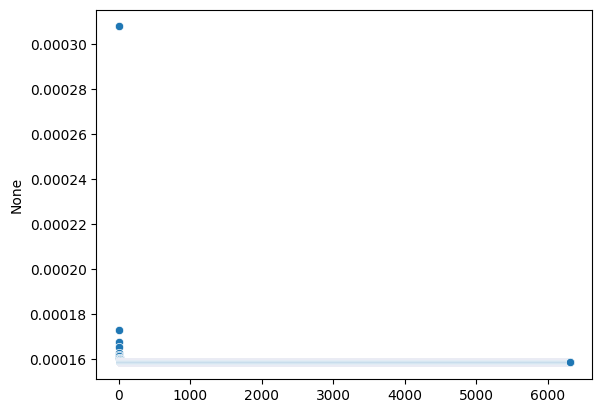

In [231]:
# mask predition
pred_m,_,A1_m,A2_m = mask.forward_test(features)
A1_m = A1_m.squeeze()
A2_m = A2_m.squeeze()
A_m = A1_m
# A_m = A2_m
print(torch.nn.functional.softmax(pred_m))
# cam
cam_m = get_cam_1d(mask.head,mask.embedding1(features.squeeze(0)),A_m)
cam_m = torch.nn.functional.softmax(cam_m,dim=0)
cam_m = cam_m[1]
cam_thr = cam_m.max()
print(cam_thr)
# softmax
A_m = torch.nn.functional.softmax(A_m)
_a,_ = torch.sort(A_m,descending=True)
_a_vis = (_a - _a.min()) / (_a.max() - _a.min())
sns.scatterplot(x=np.array(list(range(_a.size(0)))),y=_a)

In [ ]:
# ab-mil
pred_b,A_b = pure.forward_test(features)
A_b = A_b.squeeze()
print(torch.nn.functional.softmax(pred_b))
# cam classifier
# cam_b = get_cam_1d(pure.predictor,pure.dp(pure.patch_to_emb(features.squeeze(0))),A_b)
cam_b = get_cam_1d(pure.head,(pure.embedding(features.squeeze(0))),A_b)
cam_b = torch.nn.functional.softmax(cam_b,dim=0)
cam_b = cam_b[1]
print(cam_b.max())

# softmax
A_b = torch.nn.functional.softmax(A_b)
#A_norm = (A - A.min()) / (A.max() - A.min())
_a,_a_idx = torch.sort(A_b,descending=True)
_cam,_cam_idx = torch.sort(cam_b,descending=True)
print(_cam[:3])
sns.scatterplot(x=np.array(list(range(_a.size(0)))),y=_a)

In [ ]:
# compute A
pred,A = attn(features, True,True)
A = A.squeeze()
print(torch.nn.functional.softmax(pred))
# cam
# cam = get_cam_1d(attn.classifier[0],attn.feature(features.squeeze(0)),A)
# # A = torch.nn.functional.softmax(cam[0])
# A = cam[1]

# softmax
A = torch.nn.functional.softmax(A)
A_norm = (A - A.min()) / (A.max() - A.min())
_a,_ = torch.sort(A_norm,descending=True)
sns.scatterplot(x=np.array(list(range(_a.size(0)))),y=_a)

In [ ]:
# compute A
pred,A = swin(features, True,True)
A = A.squeeze()
print(torch.nn.functional.softmax(pred))
# softmax
#A = torch.nn.functional.softmax(A)
# cam
cam = get_cam_1d(swin.predictor,swin.online_encoder(swin.dp(swin.patch_to_emb(features.squeeze(0))),no_pool=True),A)
cam = torch.nn.functional.softmax(cam,dim=0)
cam = cam[1]
_a,_ = torch.sort(A,descending=True)
_cam,_cam_idx = torch.sort(cam,descending=True)

#sns.scatterplot(x=np.array(list(range(_a.size(0)))),y=_a)
sns.scatterplot(x=np.array(list(range(_cam.size(0)))),y=_cam)

## find the roi

In [ ]:
patch_num = 1
patch_size = 512
if json_data is not None:
    for _pos in range(len(json_data['positive'])):
        _,_,_,_,area = get_area(np.array(json_data['positive'][_pos]['vertices']),width_height=[width,height])
        if area >= (patch_size*patch_num)**2:
            print(_pos,area**0.5 / patch_size)

In [210]:
crop_size = 512  
stride = 512  
vis_level = 3           
vis_size = None # 448   
roi = 17 # -1->global, i->roi_index, roi_index 对应上一个代码块的输出，对tumor slide有用
alpha = .4  # 0-no_img,1-all_img
margin_percentage = 1.5 #放缩，越大越小
roi_coord = None  
rel_norm = False  
filter_thr = 0. 
filter_thr_cam = 0.49995
is_norm = True    
save_figure = False
vis_model = 'mask'  
#vis_model = 'attn' 
_c_cam = np.array([0,255,255])  
_c_attn = np.array([255,255,255]) 

## Attention + CAM

In [ ]:
# plt.figure(figsize=(6,6),dpi=300)

if vis_model == 'attn':
    _A = A_b
    __cam = cam_b
    f_name = 'ABMIL_'
elif vis_model == 'mask':
    _A = A_m
    __cam = cam_m
    f_name = 'MASK_'

if roi_coord is None:
    if roi >= 0:
        if json_data is not None:
            pos_anchors = np.array(json_data['positive'][roi]['vertices'])
            top,down,left,right,_ = get_area(pos_anchors,margin_percentage,width_height=[width,height])
        else:
            top,down,left,right,_ = get_area(None,margin_percentage,coords[_a_idx[0]],width_height=[width,height])
    else:
        top,down,left,right = 0,height,0,width
    crop_coords = []
    for i in range(top, down, stride):
        for j in range(left, right, stride):
            if j + crop_size > width or i + crop_size > height:
                continue
            crop_coords.append((j, i))
    right, down = np.max(crop_coords, 0) + crop_size
else:
    top,down,left,right = roi_coord
print(">>>>>>>>>>>> region coord gotten >>>>>>>>>>>")

scale_level_ratio = np.array(slide.level_dimensions[vis_level]) / np.array(slide.level_dimensions[0])
_w,_h = np.array((right-left, down-top))*scale_level_ratio
# _w,_h = (right-left, down-top)
region = slide.read_region((left, top), list(range(slide.level_count))[vis_level], (int(_w),int(_h))).convert('RGB')
print(">>>>>>>>>>>> slide region gotten >>>>>>>>>>>")
#
A_roi,coords_roi,cam_roi = screen_coords(_A,coords,(left,top),(right,down),cam=__cam)
print(">>>>>>>>>>cam_roi>>>>>>>>>>>>")
sorted_indices = np.argsort(cam_roi)
print(cam_roi[sorted_indices[-5:]])
#
img = np.array(region)
# 
coords_roi_rel = []
for i in range(len(coords_roi)):
    rel_x = coords_roi[i][0]-left
    rel_y = coords_roi[i][1] - top
    rel_x,rel_y = np.clip(rel_x,0,right-left),np.clip(rel_y,0,down-top)
    coords_roi_rel.append([rel_x,rel_y])
print(">>>>>>>>>>>> relative coords computed >>>>>>>>>>>")
# 
if is_norm:
    if rel_norm:
        A_roi = (A_roi - A_roi.min()) / (A_roi.max() - A_roi.min())
    else:
        A_roi = (A_roi - _A.min()) / (_A.max() - _A.min())
A_roi[A_roi<filter_thr] = 0
cam_roi[cam_roi <= filter_thr_cam] = 0

heatmap_attn = np.zeros(img.shape)
heatmap_cam = np.zeros(img.shape)
alpha_mat_attn = np.ones(img.shape) * 0.5 * alpha
alpha_mat_cam = np.ones(img.shape) * 0.5 * alpha

for _idx,_coord in enumerate(coords_roi_rel):
    A_flag = False
    cam_flag = False

    if A_roi[_idx] != 0:
        heatmap_attn[int(_coord[1]*scale_level_ratio[1]):int((_coord[1]+patch_size)*scale_level_ratio[1]),int(_coord[0]*scale_level_ratio[0]):int((_coord[0]+patch_size)*scale_level_ratio[0]),:] = A_roi[_idx] * _c_attn
        A_flag = True
    if cam_roi[_idx] != 0:
        alpha_mat_attn[int(_coord[1]*scale_level_ratio[1]):int((_coord[1]+patch_size)*scale_level_ratio[1]),int(_coord[0]*scale_level_ratio[0]):int((_coord[0]+patch_size)*scale_level_ratio[0]),:] = 0
        heatmap_attn[int(_coord[1]*scale_level_ratio[1]):int((_coord[1]+patch_size)*scale_level_ratio[1]),int(_coord[0]*scale_level_ratio[0]):int((_coord[0]+patch_size)*scale_level_ratio[0]),:] = 0
        alpha_mat_cam[int(_coord[1]*scale_level_ratio[1]):int((_coord[1]+patch_size)*scale_level_ratio[1]),int(_coord[0]*scale_level_ratio[0]):int((_coord[0]+patch_size)*scale_level_ratio[0]),:] = 1-cam_roi[_idx]

        heatmap_cam[int(_coord[1]*scale_level_ratio[1]):int((_coord[1]+patch_size)*scale_level_ratio[1]),int(_coord[0]*scale_level_ratio[0]):int((_coord[0]+patch_size)*scale_level_ratio[0]),:] = _c_cam

        cam_flag = True
    else:
        alpha_mat_cam[int(_coord[1]*scale_level_ratio[1]):int((_coord[1]+patch_size)*scale_level_ratio[1]),int(_coord[0]*scale_level_ratio[0]):int((_coord[0]+patch_size)*scale_level_ratio[0]),:] = 0

    if not A_flag and not cam_flag:

        alpha_mat_attn[int(_coord[1]*scale_level_ratio[1]):int((_coord[1]+patch_size)*scale_level_ratio[1]),int(_coord[0]*scale_level_ratio[0]):int((_coord[0]+patch_size)*scale_level_ratio[0]),:] = alpha
print(">>>>>>>>>>>> heatmap computed >>>>>>>>>>>")
#

blended_image = (alpha_mat_attn * img + alpha_mat_cam*img + (1-alpha_mat_attn) * heatmap_attn + (1-alpha_mat_cam) * heatmap_cam)
blended_image = blended_image.astype(np.uint8)

if vis_size is not None:
    plt.imshow(cv2.resize(blended_image,dsize=(vis_size,vis_size)))
    scale_ratio = (vis_size / img.shape[0])*scale_level_ratio
else:
    plt.imshow(blended_image)
    scale_ratio = scale_level_ratio
print(">>>>>>>>>>>> heatmap draw done>>>>>>>>>>>")
plt.xlim(0,(right-left)*scale_ratio[0])
plt.ylim((down-top)*scale_ratio[1],0)
plt.axis("off")

if json_data is not None:
    for anchors in (json_data['positive']):
        _pos_anchors = np.array(anchors['vertices'])
        plt.plot((_pos_anchors[:, 0]-left) * scale_ratio[0] , (_pos_anchors[:,1]-top)* scale_ratio[1], color=(0,128/255,1),linewidth=3.0)

# if save_figure:
#path = os.path.join("./vis_figure/sup/tumor/",f_id+f_name+str(roi)+'.png')
#plt.savefig(path,dpi=450,bbox_inches='tight')

## Attention

In [248]:
vis_model = 'mask'  # attn or mask 
is_norm = True
alpha=0.2
filter_thr = 0.
enhance_factor=12
roi = 0

>>>>>>>>>>>> region coord gotten >>>>>>>>>>>
>>>>>>>>>>>> slide region gotten >>>>>>>>>>>
>>>>>>>>>>>> relative coords computed >>>>>>>>>>>
>>>>>>>>>>>> heatmap computed >>>>>>>>>>>
>>>>>>>>>>>> heatmap draw done>>>>>>>>>>>


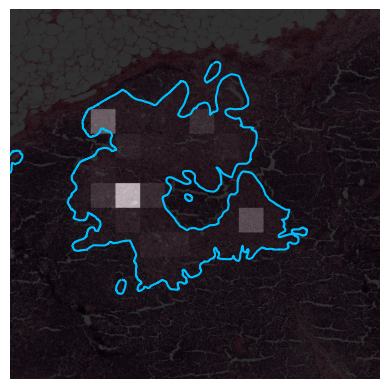

In [249]:
if vis_model == 'attn':
    _A = A_b
    __cam = cam_b
    f_name = 'ABMIL_'
elif vis_model == 'mask':
    _A = A_m
    __cam = cam_m
    f_name = 'MASK_'
elif vis_model == 'tea':
    _A = A_tea
    f_name = 'TEA_'
elif vis_model == 'mhim':
    _A = A_mask
    f_name = 'TEA_'
if roi_coord is None:
    if roi >= 0:
        if json_data is not None:
            pos_anchors = np.array(json_data['positive'][roi]['vertices'])
            top,down,left,right,_ = get_area(pos_anchors,margin_percentage,width_height=[width,height])
        else:
            top,down,left,right,_ = get_area(None,margin_percentage,coords[_a_idx[1]],width_height=[width,height])
    else:
        top,down,left,right = 0,height,0,width
    crop_coords = []
    # print(top,down,left,right)
    for i in range(top, down, stride):
        for j in range(left, right, stride):
            if j + crop_size > width or i + crop_size > height:
                continue
            crop_coords.append((j, i))
    right, down = np.max(crop_coords, 0) + crop_size
else:
    top,down,left,right = roi_coord
print(">>>>>>>>>>>> region coord gotten >>>>>>>>>>>")

scale_level_ratio = np.array(slide.level_dimensions[vis_level]) / np.array(slide.level_dimensions[0])
_w,_h = np.array((right-left, down-top))*scale_level_ratio
# _w,_h = (right-left, down-top)
region = slide.read_region((left, top), list(range(slide.level_count))[vis_level], (int(_w),int(_h))).convert('RGB')
print(">>>>>>>>>>>> slide region gotten >>>>>>>>>>>")
#
A_roi,coords_roi = screen_coords(_A,coords,(left,top),(right,down))
#
img = np.array(region)
# 
coords_roi_rel = []
for i in range(len(coords_roi)):
    rel_x = coords_roi[i][0]-left
    rel_y = coords_roi[i][1] - top
    rel_x,rel_y = np.clip(rel_x,0,right-left),np.clip(rel_y,0,down-top)
    coords_roi_rel.append([rel_x,rel_y])
print(">>>>>>>>>>>> relative coords computed >>>>>>>>>>>")
# 
if is_norm:
    if rel_norm:
        A_roi = (A_roi - A_roi.min()) / (A_roi.max() - A_roi.min())
    else:
        A_roi = (A_roi - _A.min()) / (_A.max() - _A.min())
A_roi[A_roi<filter_thr] = 0
A_roi = A_roi * enhance_factor

heatmap = np.zeros(img.shape)
alpha_mat = np.ones(img.shape) *  alpha
for _idx,_coord in enumerate(coords_roi_rel):
    heatmap[int(_coord[1]*scale_level_ratio[1]):int((_coord[1]+patch_size)*scale_level_ratio[1]),int(_coord[0]*scale_level_ratio[0]):int((_coord[0]+patch_size)*scale_level_ratio[0]),:] = A_roi[_idx] * 255

print(">>>>>>>>>>>> heatmap computed >>>>>>>>>>>")
#
blended_image = (alpha * img + (1-alpha) * heatmap[:, :, :3])
blended_image = blended_image.astype(np.uint8)

if vis_size is not None:
    plt.imshow(cv2.resize(blended_image,dsize=(vis_size,vis_size)))
    scale_ratio = (vis_size / img.shape[0])*scale_level_ratio
else:
    plt.imshow(blended_image)
    scale_ratio = scale_level_ratio
print(">>>>>>>>>>>> heatmap draw done>>>>>>>>>>>")
plt.xlim(0,(right-left)*scale_ratio[0])
plt.ylim((down-top)*scale_ratio[1],0)
plt.axis("off")

if json_data is not None:
    for anchors in (json_data['positive']):
        _pos_anchors = np.array(anchors['vertices'])
        plt.plot((_pos_anchors[:, 0]-left) * scale_ratio[0] , (_pos_anchors[:,1]-top)* scale_ratio[1], color='deepskyblue')

#path = os.path.join("./vis_figure/sup/tumor/",f_id+f_name+str(roi)+'_attn.png')
#plt.savefig(path,dpi=450,bbox_inches='tight')

## Original Image

>>>>>>>>>>>> region coord gotten >>>>>>>>>>>


FileNotFoundError: [Errno 2] No such file or directory: './vis_figure/sup/tumor_056MASK__0_ori.png'

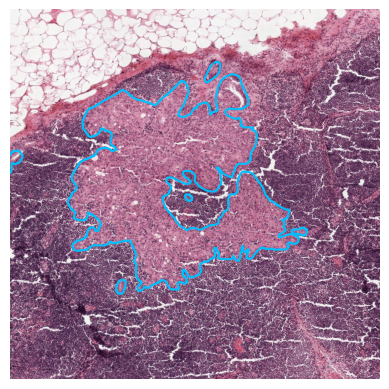

In [250]:
scale_level_ratio = np.array(slide.level_dimensions[vis_level]) / np.array(slide.level_dimensions[0])
if vis_size is not None:
    
    scale_ratio = (vis_size / img.shape[0])*scale_level_ratio
else:
    
    scale_ratio = scale_level_ratio



if roi_coord is None:
    if roi >= 0:
        if json_data is not None:
            pos_anchors = np.array(json_data['positive'][roi]['vertices'])
            top,down,left,right,_ = get_area(pos_anchors,margin_percentage,width_height=[width,height])
        else:
            top,down,left,right,_ = get_area(None,margin_percentage,coords[_a_idx[1]],width_height=[width,height])
    else:
        top,down,left,right = 0,height,0,width
    crop_coords = []
    # print(top,down,left,right)
    for i in range(top, down, stride):
        for j in range(left, right, stride):
            if j + crop_size > width or i + crop_size > height:
                continue
            crop_coords.append((j, i))
    right, down = np.max(crop_coords, 0) + crop_size
else:
    top,down,left,right = roi_coord
print(">>>>>>>>>>>> region coord gotten >>>>>>>>>>>")

scale_level_ratio = np.array(slide.level_dimensions[vis_level]) / np.array(slide.level_dimensions[0])
_w,_h = np.array((right-left, down-top))*scale_level_ratio
# _w,_h = (right-left, down-top)
region = slide.read_region((left, top), list(range(slide.level_count))[vis_level], (int(_w),int(_h))).convert('RGB')


plt.imshow(np.array(region))
plt.axis("off")
plt.xlim(0,(right-left)*scale_ratio[0])
plt.ylim((down-top)*scale_ratio[1],0)
if json_data is not None:
    for anchors in (json_data['positive']):
        _pos_anchors = np.array(anchors['vertices'])
        plt.plot((_pos_anchors[:, 0]-left) * scale_ratio[0] , (_pos_anchors[:,1]-top)* scale_ratio[1], color='deepskyblue')
path = os.path.join("./vis_figure/sup/",f_id+f_name+'_'+str(roi)+'_ori'+'.png')
plt.savefig(path,dpi=450,bbox_inches='tight')